In [72]:
import pennylane as qml
from jax import numpy as np
import jax
import optax
import matplotlib.pyplot as plt

In [54]:
jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

In [55]:
dataset = qml.data.load('qchem', molname = 'H2')[0]
H, qubits = dataset.hamiltonian, len(dataset.hamiltonian.wires)

In [56]:
dev = qml.device("default.qubit", wires = qubits)

In [57]:
electrons = 2

In [58]:
hf = qml.qchem.hf_state(electrons, qubits)

In [59]:
@qml.qnode(dev, interface = 'jax')
def ckt(param, wires):
    qml.BasisState(hf, wires = wires)
    qml.DoubleExcitation(param, wires = [0, 1, 2, 3])
    return qml.expval(H)

In [79]:
def cost_fn(param):
    return ckt(param, wires = range(qubits))

In [80]:
max_iterations = 100
tol = 1e-06
opt = optax.sgd(learning_rate = 0.1)

In [81]:
theta = np.array(0.)
energy = [cost_fn(theta)]
angle = [theta]

In [82]:
opt_state = opt.init(theta)
for _ in range(max_iterations):

    grad = jax.grad(cost_fn)(theta)
    updates, opt_state = opt.update(grad, opt_state)
    theta = optax.apply_updates(theta, updates)

    angle.append(theta)
    energy.append(cost_fn(theta))

    conv = np.abs(energy[-1] - energy[-2])

    if _ % 5 == 0:
        print(f"Step = {_}, Energy = {energy[-1]:.8f} Ha")
    if conv <= tol:
        break

Step = 0, Energy = -1.11980936 Ha
Step = 5, Energy = -1.12969524 Ha
Step = 10, Energy = -1.13399425 Ha
Step = 15, Energy = -1.13585356 Ha
Step = 20, Energy = -1.13665581 Ha
Step = 25, Energy = -1.13700160 Ha
Step = 30, Energy = -1.13715059 Ha
Step = 35, Energy = -1.13721476 Ha
Step = 40, Energy = -1.13724241 Ha
Step = 45, Energy = -1.13725431 Ha


In [83]:
print("\n" f"Final ground-state energy = {energy[-1]:.8f} Ha")
print("\n" f"Optimal value of the circuit parameter = {angle[-1]:.4f}")


Final ground-state energy = -1.13725789 Ha

Optimal value of the circuit parameter = 0.2227


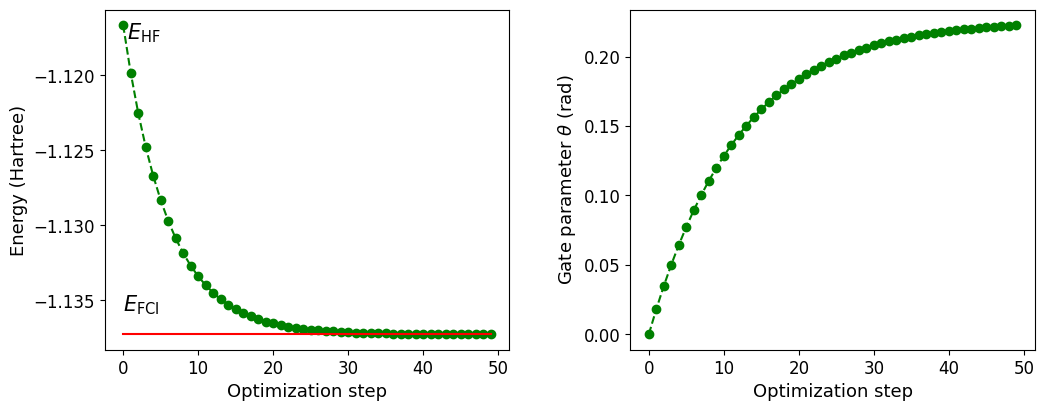

In [84]:
import matplotlib.pyplot as plt

n = _

fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(12)

# Full configuration interaction (FCI) energy computed classically
E_fci = dataset.fci_energy

# Add energy plot on column 1
ax1 = fig.add_subplot(121)
ax1.plot(range(n + 2), energy, "go", ls="dashed")
ax1.plot(range(n + 2), np.full(n + 2, E_fci), color="red")
ax1.set_xlabel("Optimization step", fontsize=13)
ax1.set_ylabel("Energy (Hartree)", fontsize=13)
ax1.text(0.5, -1.1176, r"$E_\mathrm{HF}$", fontsize=15)
ax1.text(0, -1.1357, r"$E_\mathrm{FCI}$", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add angle plot on column 2
ax2 = fig.add_subplot(122)
ax2.plot(range(n + 2), angle, "go", ls="dashed")
ax2.set_xlabel("Optimization step", fontsize=13)
ax2.set_ylabel("Gate parameter $\\theta$ (rad)", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()